# 01 — GoEmotions dataset exploration

Guide §6: split sizes, label names, counts per label, missing/empty text, duplicates, multi-label rate, examples per class, and the effect of the Mentor AI label mapping.

Run `make data` first. Figures are saved to `reports/figures/`.

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datasets import load_dataset

from src import config
from src.data import load_manifest, load_split

pd.set_option("display.max_colwidth", 160)
config.FIGURES.mkdir(parents=True, exist_ok=True)

## Raw dataset: splits, columns, label names

In [2]:
dataset = load_dataset(config.DATASET_NAME, config.DATASET_CONFIG, cache_dir=str(config.DATA_RAW))
label_names = dataset["train"].features["labels"].feature.names
print(dataset)
print(dataset["train"][0])
print(f"{len(label_names)} labels:", label_names)

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})
{'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [27], 'id': 'eebbqej'}
28 labels: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [3]:
raw = {split: dataset[split].to_pandas() for split in config.SPLITS}
train_raw = raw["train"]

summary = pd.DataFrame({
    split: {
        "rows": len(df),
        "empty_or_missing_text": int(df["text"].fillna("").str.strip().eq("").sum()),
        "duplicate_texts": int(df["text"].duplicated().sum()),
        "multi_label_rate": round(float(df["labels"].map(len).gt(1).mean()), 4),
    }
    for split, df in raw.items()
})
summary

,train,validation,test
rows,43410.0000,5426.0000,5427.0000
empty_or_missing_text,0.0000,0.0000,0.0000
duplicate_texts,183.0000,3.0000,6.0000
multi_label_rate,0.1636,0.1618,0.1542


## Examples per GoEmotions label (train)

,label,count,mentor_class
0,neutral,14219,neutral
1,admiration,4130,(dropped)
2,approval,2939,(dropped)
3,gratitude,2662,joy
4,annoyance,2470,anger_frustration
5,amusement,2328,joy
6,curiosity,2191,(dropped)
7,love,2086,joy
8,disapproval,2022,(dropped)
9,optimism,1581,motivation


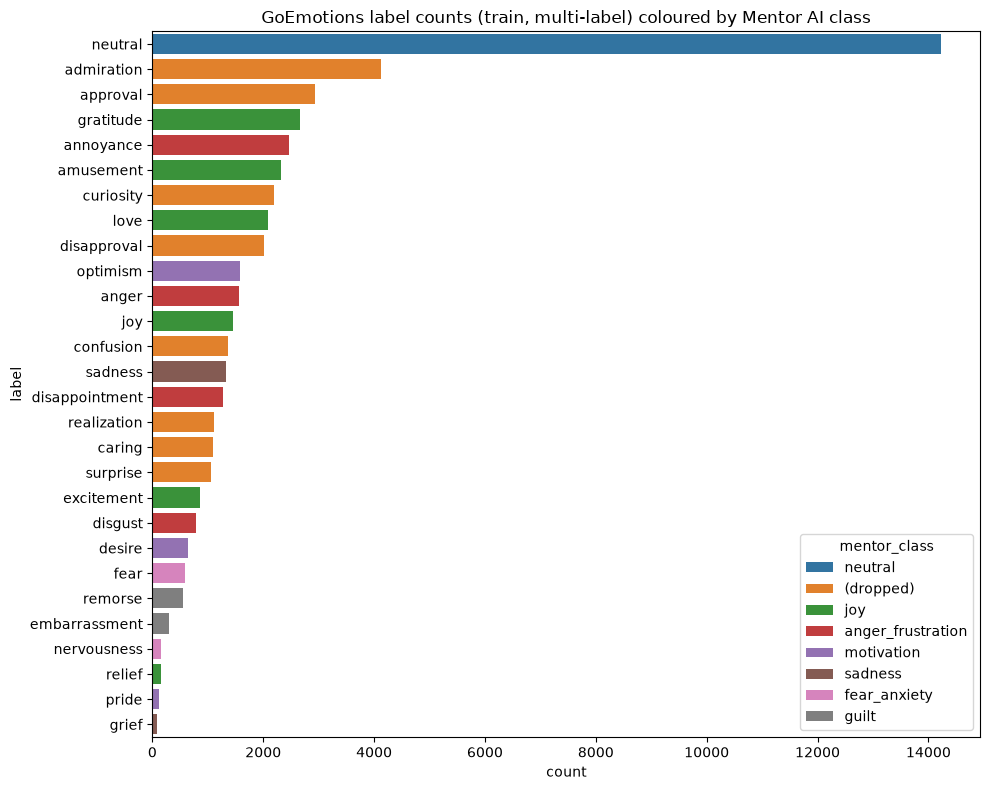

In [4]:
label_counts = (
    train_raw["labels"].explode().map(lambda i: label_names[int(i)]).value_counts()
    .rename_axis("label").reset_index(name="count")
)
source_to_mentor = {s: m for m, sources in config.MENTOR_LABEL_MAP.items() for s in sources}
label_counts["mentor_class"] = label_counts["label"].map(source_to_mentor).fillna("(dropped)")

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=label_counts, y="label", x="count", hue="mentor_class", dodge=False, ax=ax)
ax.set_title("GoEmotions label counts (train, multi-label) coloured by Mentor AI class")
fig.tight_layout()
fig.savefig(config.FIGURES / "goemotions_label_counts.png", dpi=200)
label_counts

## After Mentor AI mapping and cleaning

,train,validation,test
joy,6743,861,814
sadness,868,91,107
fear_anxiety,536,72,80
anger_frustration,4119,497,551
guilt,559,61,67
motivation,1341,186,176
neutral,12781,1591,1605


,train,validation,test
raw_rows,43410,5426,5427
kept_after_mapping,27134,3368,3405
removed_only_unmapped_labels,11182,1426,1431
removed_partially_unmapped_labels,3539,437,409
removed_conflicting_mentor_classes,1555,195,182
removed_empty_text,0,0,0
removed_exact_duplicates,108,2,5
removed_same_text_different_labels,38,0,0
removed_overlap_with_validation_or_test,41,0,0
removed_overlap_with_test,0,7,0


Dropped GoEmotions labels: ['admiration', 'approval', 'caring', 'confusion', 'curiosity', 'disapproval', 'realization', 'surprise']


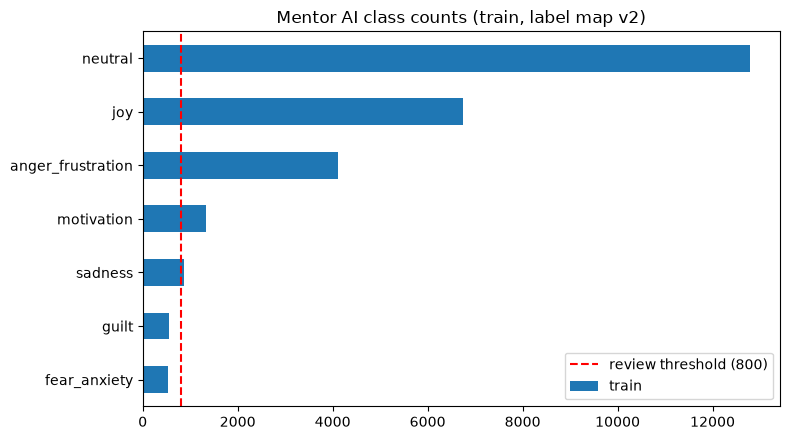

In [5]:
manifest = load_manifest()
class_counts = pd.DataFrame({s: manifest["splits"][s]["class_counts"] for s in config.SPLITS})
filtering = pd.DataFrame({s: manifest["splits"][s]["filtering"] for s in config.SPLITS}).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(8, 4.5))
class_counts["train"].sort_values().plot.barh(ax=ax)
ax.axvline(config.MIN_TRAIN_SUPPORT, color="red", linestyle="--", label=f"review threshold ({config.MIN_TRAIN_SUPPORT})")
ax.set_title(f"Mentor AI class counts (train, label map {manifest['label_map_version']})")
ax.legend()
fig.tight_layout()
fig.savefig(config.FIGURES / "mentor_class_counts.png", dpi=200)

display(class_counts)
display(filtering)
print("Dropped GoEmotions labels:", manifest["dropped_source_labels"])

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
anger_frustration,4119.0,70.6,36.6,4.0,40.0,68.0,98.0,178.0
fear_anxiety,536.0,70.8,36.2,8.0,40.0,69.0,98.0,161.0
guilt,559.0,72.3,34.2,9.0,45.0,69.0,97.5,170.0
joy,6743.0,62.1,34.6,5.0,32.0,58.0,88.0,175.0
motivation,1341.0,75.0,33.8,10.0,47.0,74.0,100.0,168.0
neutral,12781.0,67.1,38.1,2.0,35.0,63.0,95.0,542.0
sadness,868.0,68.2,36.1,10.0,36.8,67.0,96.0,182.0


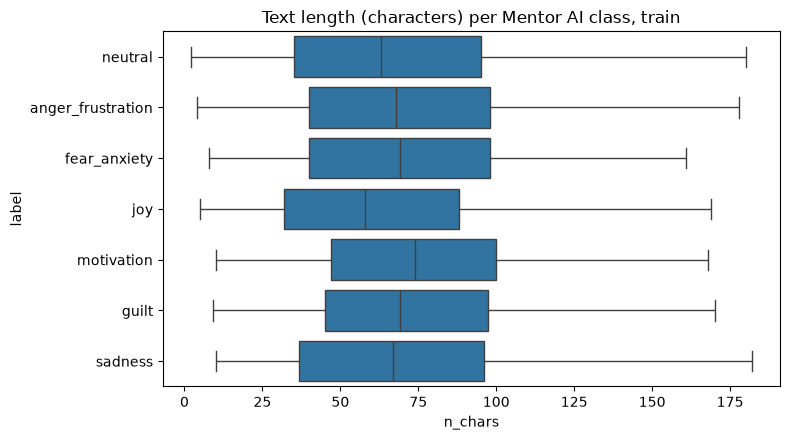

In [6]:
train = load_split("train")
train["n_chars"] = train["text"].str.len()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=train, x="n_chars", y="label", showfliers=False, ax=ax)
ax.set_title("Text length (characters) per Mentor AI class, train")
fig.tight_layout()
fig.savefig(config.FIGURES / "text_length_per_class.png", dpi=200)
train.groupby("label")["n_chars"].describe().round(1)

## Read examples from every class

Look for noisy or ambiguous labels (sarcasm, quoted emotions, very short texts). Record observations in `data/label_mapping.md`.

In [7]:
for label, group in train.groupby("label"):
    print(f"\n=== {label} ({len(group)}) ===")
    for text in group.sample(8, random_state=config.SEED)["text"]:
        print(" -", text)


=== anger_frustration (4119) ===
 - 50 becoz I’ve used before and it’s A really intense high but after a bit of research I’m extremely hesitant to use it again
 - Shrug. Cant blame anyone other than your parents.
 - If you're more concerned about a potential person than an actual person, you should get out of medicine. You aren't qualified.
 - I'm sick of them eating my cheddar.
 - My name is [NAME]. You killed my father, prepare to die.
 - Minimum wage hurts small business more than it helps the poor.
 - Yikes, what a loony bird.
 - I think [NAME] is starting to get too much blame, everybody on the roster sucks with the exception of [NAME]

=== fear_anxiety (536) ===
 - [NAME] and [NAME] for [NAME] then sign [NAME] afraid this battle station is fully operational
 - I am. He's the easy pick. Would be perfect for this franchise. I'm worried that he won't make it to us.
 - I graduated in 2002 and had history books that ended with [NAME] 2nd term. I had great teachers but terrible materi